# This notebook describes work done in support of PR #369.

# Pipeline Stage-by-Stage Debugger

A debugging notebook where **each pipeline sub-step gets its own cell** so
we can inspect each intermediate step in isolation — before moving to the next cell. This helps us understand how the method works, how different steps in the process impact the results, and diagnose and resolve any issues.

Every cell calls `inspect()`, which:
1. Runs the same three formal QA checks (`all_nan`, `out_of_range`,
   `sporadic_nan_days`) from `srm.qa_checks` — the same checks a
   `bcsd qa` run applies to a cached artifact.
2. Prints a PASS/FAIL verdict per check.
3. Plots a spatial map (`time=0`) and a domain-mean time series.
4. Registers the computed array in the `STEPS` dict so the cross-stage
   evolution plots at the bottom can iterate over every step.



In [1]:
%load_ext autoreload
%autoreload 2

import textwrap
import warnings

import matplotlib.pyplot as plt
import numpy as np
import rasterix  # noqa: F401  # registers .proj/.rio accessors
import xarray as xr
import xarray_regrid  # noqa: F401  # registers .regrid namespace

from srm.bcsd_config import BCSDConfig, PipelineOptions
from srm.downscaling_utils import (
    calculate_doy_means,
    downscale_from_coarse,
    get_historical_experiment,
    get_obs,
    interpolate_coarse_to_fine_grid,
    interpolate_fine_to_coarse_grid,
    retrend,
    subset_space
)
from srm.pipeline import BCSDPipeline
from srm.qa_checks import _STATUS_SYMBOL, run_artifact_checks
from srm.validation import CheckStatus

warnings.filterwarnings("ignore", category=FutureWarning)


def _step_title(step: str, width: int = 16) -> str:
    """Wrap a snake_case step name to fit in a narrow subplot title."""
    return textwrap.fill(step.replace("_", " "), width=width)

## Config

**Edit only this cell** between debug runs. Set `SCENARIO = None` to debug
Stage 1 + Stage 2 only; set a scenario string to also exercise Stage 3.

`scratch_dir` and `output_dir` point to a local tmp directory so no debug
writes touch the real S3 cache.


In [7]:
# ── Edit these values ──────────────────────────────────────────────────────────
GCM = "CESM2-WACCM"
VARIABLE = "rsds"
ENSEMBLE_MEMBER = "001"  # CESM2-WACCM SSP245/G6-1.5K uses numeric IDs; "001" → hist r1i1p1f1
SCENARIO = "None"

# Use sample area in arctic to see what happens with polar winter
# (lat_min, lat_max, lon_min, lon_max)
SUBSET_BOUNDS = (60, 80, 15.0, 39.0)
# ──────────────────────────────────────────────────────────────────────────────

config = BCSDConfig(
    gcm=GCM,
    variable=VARIABLE,
    ensemble_member=ENSEMBLE_MEMBER,
    scenario=SCENARIO,
    # predict_period_start must equal the scenario data start (2015 for SSP245)
    # so stitch_historical_scenario produces a gap-free 1978–end timeseries.
    predict_period_start=2015 if SCENARIO else None,
    predict_period_end=2060 if SCENARIO else None,
    subset_bounds=SUBSET_BOUNDS
)
options = PipelineOptions(
    scratch_dir="/tmp/bcsd-debug/scratch/",  # local — never touches S3
    output_dir="/tmp/bcsd-debug/output/",
    branch="debug",
    environment="debug",
)
pipeline = BCSDPipeline(config, options)
print(f"Run: {config.run_id}")
print(f"Subset bounds: {config.subset_bounds}")
print(f"Scenario: {config.scenario!r}")
print(f"Predict period: {config.predict_period_start}–{config.predict_period_end}")

Run: CESM2-WACCM_rsds_001_NONE_subset
Subset bounds: (60.0, 80.0, 15.0, 39.0)
Scenario: 'NONE'
Predict period: 2015–2060


## Inspection helper

`inspect(da, stage)` is called after every sub-step. It:
- `.compute()`s the DataArray (fine for the small subset region)
- Runs `run_artifact_checks()` (skipped for arrays with a `dayofyear` dim
  instead of a `time` dim, since those lack the time axis the checks need)
- Prints a PASS/FAIL line per check with detail for any non-PASS result
- Plots spatial map + domain-mean series
- Registers `da` in `STEPS` and its NaN fraction in `STEP_NAN_FRACTIONS`


In [8]:
STEPS: dict[str, xr.DataArray] = {}  # ordered; keys = step labels
STEP_NAN_FRACTIONS: dict[str, float] = {}  # per-step nan_fraction for bar chart


def inspect(
    da: xr.DataArray,
    stage: str,
    *,
    skip_qa: bool = False,
) -> xr.DataArray:
    """Compute, QA-check, plot, and register a pipeline intermediate."""
    print(f"\n{'=' * 60}")
    print(f"  {stage}")
    print(f"{'=' * 60}")

    da = da.compute()
    STEPS[stage] = da

    has_time = "time" in da.dims
    has_doy = "dayofyear" in da.dims

    # ── QA checks ─────────────────────────────────────────────────────────────
    if not skip_qa and has_time:
        results = run_artifact_checks(
            da,
            gcm=config.gcm,
            variable=config.variable,
            ensemble_member=config.ensemble_member,
            scenario=config.scenario,
            stage=stage,
        )
        STEP_NAN_FRACTIONS[stage] = results["all_nan"].nan_fraction
        for check_name, result in results.items():
            sym = _STATUS_SYMBOL[result.status]
            line = f"  {sym} {check_name}: {result.status.upper()}"
            if result.message:
                line += f" — {result.message}"
            print(line)
            if result.status not in (CheckStatus.PASS, CheckStatus.SKIP) and result.detail:
                for k, v in result.detail.items():
                    print(f"        {k}: {v}")
    elif has_doy:
        print("  (QA checks skipped — dayofyear dimension, no time axis)")
    else:
        print("  (QA checks skipped)")

    # ── Summary ───────────────────────────────────────────────────────────────
    print(f"  shape: {dict(da.sizes)}")
    if has_time or has_doy:
        nan_frac = float(np.isnan(da.values).mean())
        print(f"  NaN:   {nan_frac:.4f} ({nan_frac * 100:.2f}%)")

    # ── Plots ─────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(stage, fontsize=12, fontweight="bold")
    try:
        if has_time:
            da.isel(time=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("time=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean time series")
        elif has_doy:
            da.isel(dayofyear=0).plot(ax=axes[0], add_colorbar=True)
            axes[0].set_title("dayofyear=0 (spatial map)")
            da.mean(["lat", "lon"]).plot(ax=axes[1])
            axes[1].set_title("domain-mean DOY series")
        else:
            for ax in axes:
                ax.text(0.5, 0.5, "no time/dayofyear dim", transform=ax.transAxes, ha="center")
    except Exception as exc:
        for ax in axes:
            ax.text(
                0.5,
                0.5,
                f"plot error:\n{exc}",
                transform=ax.transAxes,
                ha="center",
                fontsize=8,
                wrap=True,
            )
    plt.tight_layout()
    plt.show()
    return da

## ERA5-relative exceedance helpers

Adapted from `synced/notebooks/check_reasonable_ranges.ipynb`. Unlike the
global physical-bounds check in `qa_checks.py`, these compare the downscaled
output against ERA5's **per-pixel** historical min/max — so a value that is
physically plausible globally but implausible at that specific location is
still flagged.

`obs_fine_s2` / `obs_fine_s3` (already in memory) serve as the ERA5
reference, so no extra S3 reads are needed.


In [9]:
try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    _HAS_CARTOPY = True
except ImportError:
    _HAS_CARTOPY = False

_MONTH_NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

# Grey for zero exceedances; continuous Reds for nonzero — makes clean regions
# immediately obvious without needing a separate mask plot.
_EXCEEDANCE_CMAP = plt.cm.Reds.copy()
_EXCEEDANCE_CMAP.set_under("lightgrey")


def _era5_threshold(obs_fine: xr.DataArray, direction: str, period: str) -> xr.DataArray:
    """Per-pixel ERA5 min/max from obs_fine already in memory.

    Parameters
    ----------
    obs_fine : already-computed fine-grid ERA5 DataArray
    direction : "gt" → max threshold; "lt" → min threshold
    period    : "annual" or "monthly"
    """
    fn = "max" if direction == "gt" else "min"
    if period == "annual":
        return getattr(obs_fine, fn)("time").compute()
    return getattr(obs_fine.groupby("time.month"), fn)("time").compute()


def _count_exceedances(
    da: xr.DataArray,
    threshold: xr.DataArray,
    direction: str,
    period: str,
) -> xr.DataArray:
    """Number of time steps per pixel that exceed the given threshold."""
    if period == "annual":
        mask = da > threshold if direction == "gt" else da < threshold
        return mask.sum("time").compute()
    counts = []
    for m, group in da.groupby("time.month"):
        exceeded = (
            group > threshold.sel(month=m) if direction == "gt" else group < threshold.sel(month=m)
        )
        counts.append(exceeded.sum("time").expand_dims(month=[m]))
    return xr.concat(counts, dim="month").compute()


def _plot_map(da, ax, title, **kw):
    """Single-panel map with optional cartopy coastlines."""
    proj_kw = {"transform": ccrs.PlateCarree()} if _HAS_CARTOPY else {}
    da.plot(ax=ax, **kw, **proj_kw)
    if _HAS_CARTOPY:
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.set_title(title, fontsize=9)


def plot_time_extremes(da: xr.DataArray, label: str) -> None:
    """2×2 grid: time-min and time-max with default and robust color scaling."""
    proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
    fig, axes = plt.subplots(2, 2, figsize=(14, 8), subplot_kw=proj)
    fig.suptitle(f"{label} — time extremes", fontweight="bold")
    _plot_map(da.min("time"), axes[0, 0], "time min")
    _plot_map(da.max("time"), axes[0, 1], "time max")
    _plot_map(da.min("time"), axes[1, 0], "time min (robust)", robust=True)
    _plot_map(da.max("time"), axes[1, 1], "time max (robust)", robust=True)
    plt.tight_layout()
    plt.show()


def check_era5_exceedances(
    da: xr.DataArray,
    obs_fine: xr.DataArray,
    label: str,
    period: str = "annual",
) -> None:
    """Flag pixels where da ever exceeds ERA5's per-pixel historical min/max.

    Prints pixel counts and plots exceedance maps (grey = clean, Reds = flagged).
    Set period="monthly" for a 3×4 faceted map — slower but more granular.
    """
    print(f"\n── ERA5-relative exceedance: {label} ({period}) ──")
    n_pixels = int(da.isel(time=0).size)

    for direction, label_suffix in [("gt", "days > ERA5 max"), ("lt", "days < ERA5 min")]:
        thresh = _era5_threshold(obs_fine, direction, period)
        count = _count_exceedances(da, thresh, direction, period)

        n_flagged = int((count > 0).sum().values)
        pct = n_flagged / n_pixels
        sym = "✗" if n_flagged > 0 else "✓"
        print(f"  {sym} {label_suffix}: {n_flagged}/{n_pixels} pixels flagged ({pct:.1%})")

        proj = dict(projection=ccrs.PlateCarree()) if _HAS_CARTOPY else {}
        if period == "annual":
            fig, ax = plt.subplots(figsize=(8, 5), subplot_kw=proj)
            _plot_map(count, ax, f"{label}\n{label_suffix}", cmap=_EXCEEDANCE_CMAP, vmin=0.5)
            plt.tight_layout()
            plt.show()
        else:
            fig, axes = plt.subplots(3, 4, figsize=(20, 10), subplot_kw=proj)
            fig.suptitle(f"{label}\n{label_suffix}", fontsize=11)
            for i, ax in enumerate(axes.flat):
                _plot_map(
                    count.sel(month=i + 1),
                    ax,
                    _MONTH_NAMES[i],
                    cmap=_EXCEEDANCE_CMAP,
                    vmin=0.5,
                )
            plt.tight_layout()
            plt.show()

## Stage 1 — `prepare_observations`

Replicates the internals of `BCSDPipeline.prepare_observations` step by step. The final cell writes the result to the debug cache so Stage 2's `_load_gcm_obs()` can find it.



  obs_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0000 (0.00%)


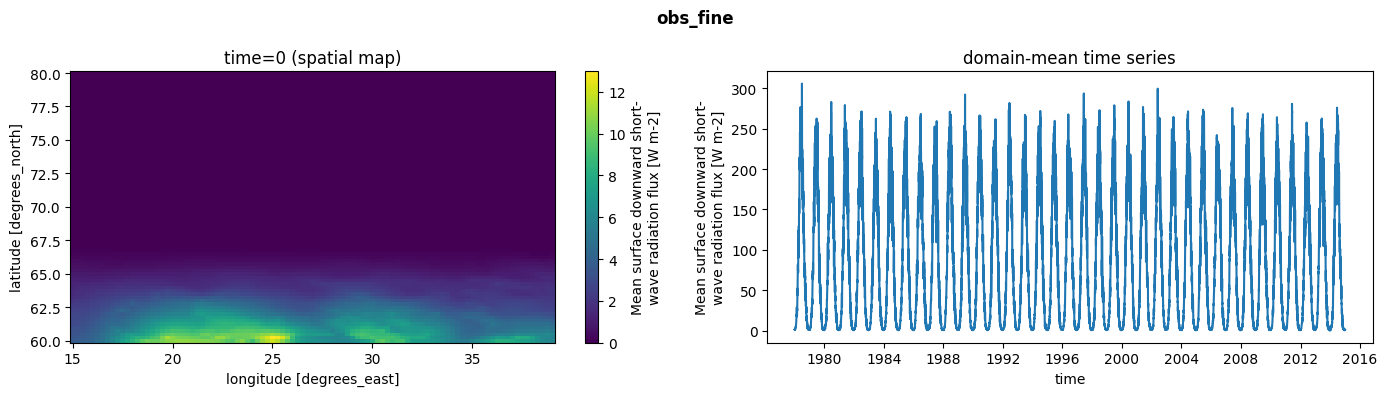

In [10]:
# ── obs_fine: fine-resolution ERA5 observations ───────────────────────────────
obs_fine = get_obs(var=config.variable, dataset_name=config.obs_dataset)
obs_fine = obs_fine.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    obs_fine = subset_space(obs_fine, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max))
train_slice = slice(str(config.train_period_start), str(config.train_period_end))
obs_fine = obs_fine.sel(time=train_slice)
obs_fine = inspect(obs_fine, "obs_fine")


  model_grid
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


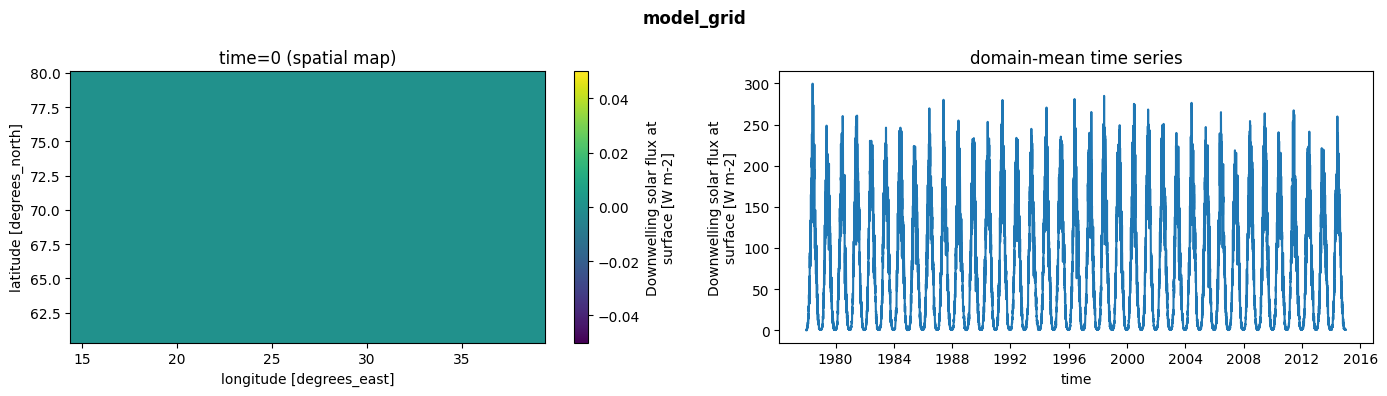

In [11]:
# ── model_grid: GCM historical run (used only as a coarse grid template) ──────
model_grid = get_historical_experiment(
    gcm=config.gcm, member=pipeline._hist_member, var=config.variable
)
model_grid = model_grid.drop_vars("spatial_ref", errors="ignore")
if config.subset_bounds:
    lat_min, lat_max, lon_min, lon_max = config.subset_bounds
    model_grid = subset_space(
        model_grid, lat_bounds=(lat_min, lat_max), lon_bounds=(lon_min, lon_max)
    )
model_grid = model_grid.sel(time=train_slice)
model_grid = inspect(model_grid, "model_grid")


  obs_coarse_stage1
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


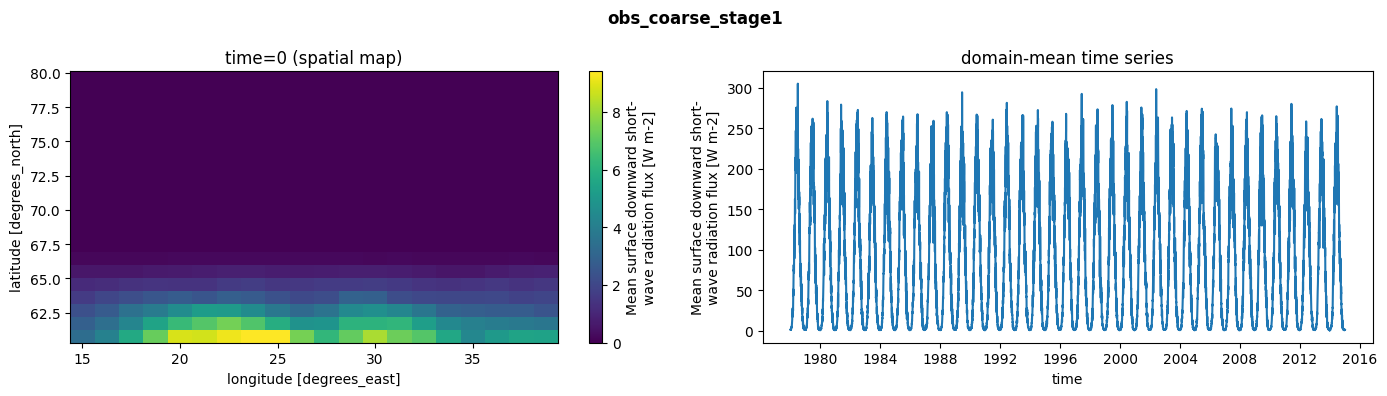

In [12]:
# ── obs_coarse: ERA5 obs regridded to the GCM coarse grid ─────────────────────
obs_coarse_stage1 = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine, da_coarse_grid=model_grid
)
obs_coarse_stage1 = inspect(obs_coarse_stage1, "obs_coarse_stage1")

In [13]:
%%time
# ── Write to debug cache so Stage 2 _load_gcm_obs() can find obs_regridded ───
# This is equivalent to running prepare_observations() but on the debug branch.
# force=True overwrites any previous debug-branch artifact.
print("Writing obs_coarse to debug cache via prepare_observations(force=True) ...")
prepare_obs_path = pipeline.prepare_observations(force=True)
print(f"  → {prepare_obs_path}")

Writing obs_coarse to debug cache via prepare_observations(force=True) ...
  2026-07-01T23:41:23.566334Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-01T23:41:23.925787Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  → /tmp/bcsd-debug/scratch/debug/CESM2-WACCM-ERA5-lat60.0to80.0_lon15.0to39.0.icechunk
CPU times: user 3min 24s, sys: 1min 35s, total: 4min 59s
Wall time: 2min 7s


## Stage 2 — `fit_historical` (debiasing + spatial downscaling)


  2026-07-01T23:43:30.737963Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196

  2026-07-01T23:43:30.738591Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196


  obs_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


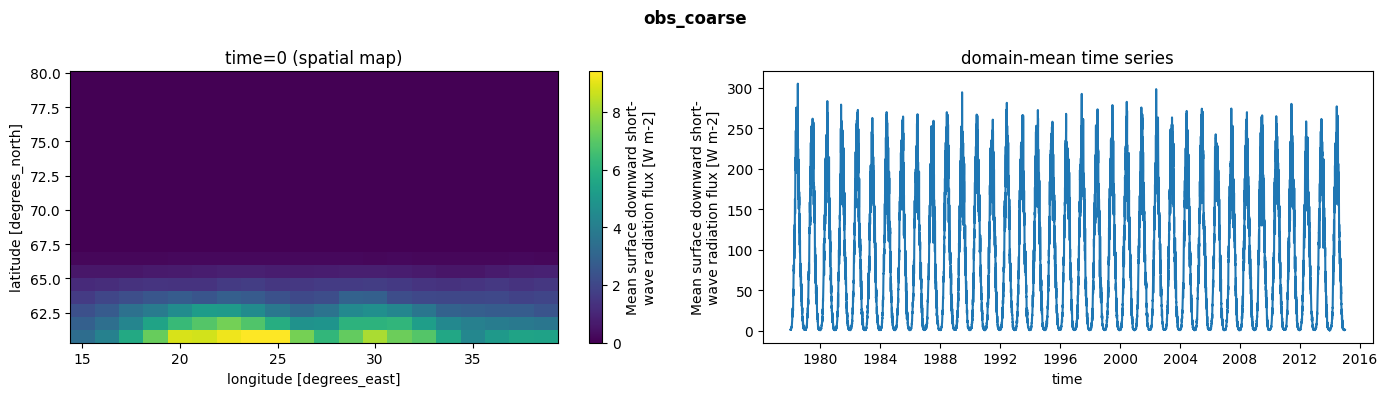


  obs_fine_s2
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0000 (0.00%)


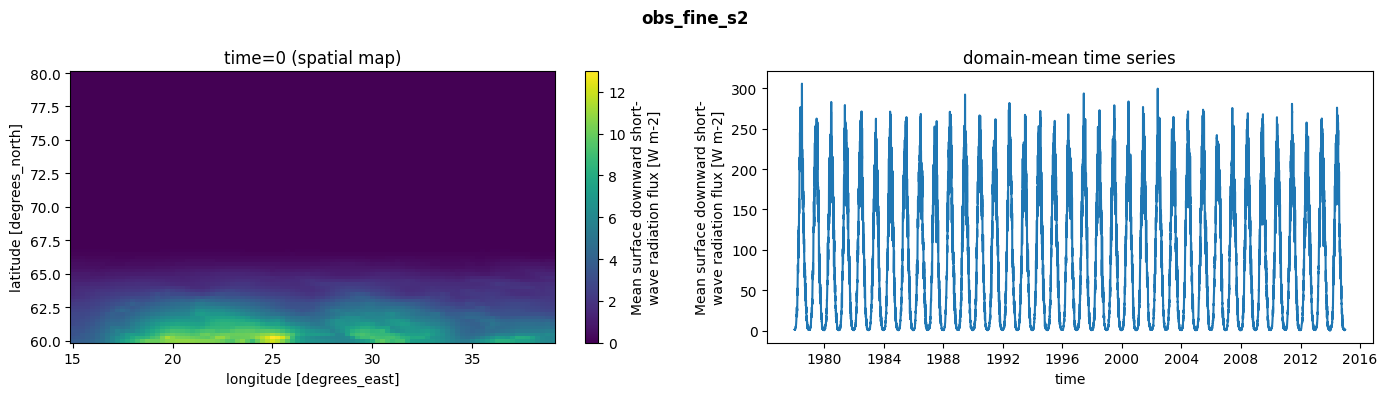


  model_hist
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


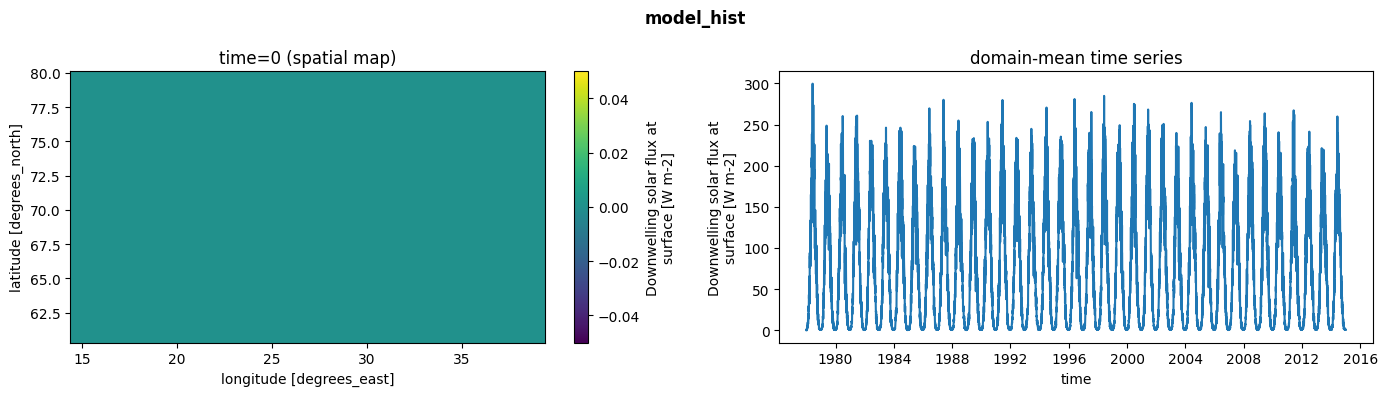

CPU times: user 1min 55s, sys: 52.7 s, total: 2min 48s
Wall time: 58.9 s


In [14]:
%%time
# ── _load_gcm_obs: reload from debug cache + load obs_fine, model_hist ────────
obs_coarse, obs_fine_s2, model_hist = pipeline._load_gcm_obs()
obs_coarse = inspect(obs_coarse, "obs_coarse")
obs_fine_s2 = inspect(obs_fine_s2, "obs_fine_s2")
model_hist = inspect(model_hist, "model_hist")


  debiased_coarse
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


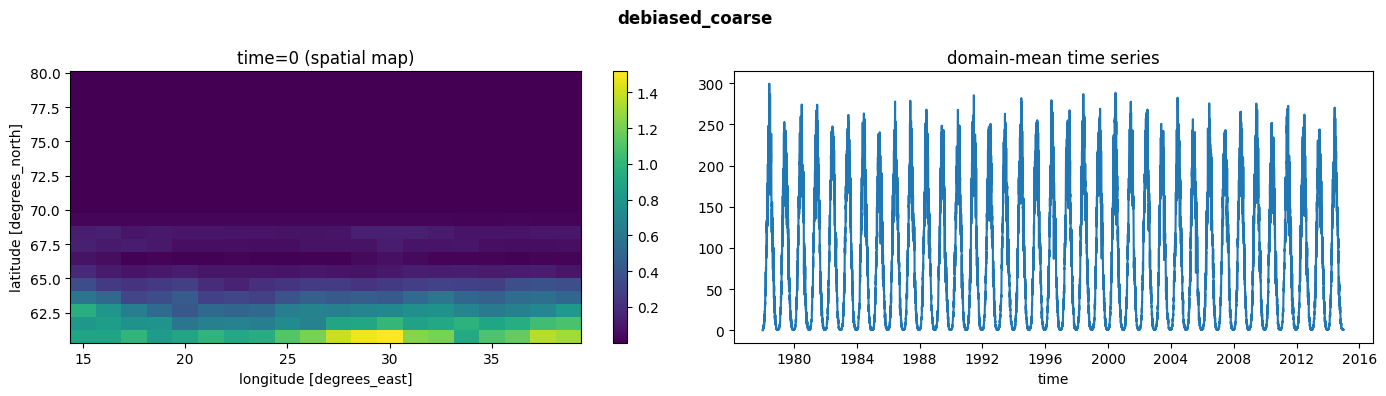

CPU times: user 314 ms, sys: 723 ms, total: 1.04 s
Wall time: 5.29 s


In [15]:
%%time
# ── _apply_bias_correction: ibicus QuantileMapping on historical period ────────
# It calls .values / .load() internally so it is always eager; runtime ~ 1–5 min
# on the South Africa subset.
debiased_coarse = pipeline._apply_bias_correction(obs_coarse, model_hist)
debiased_coarse = inspect(debiased_coarse, "debiased_coarse")

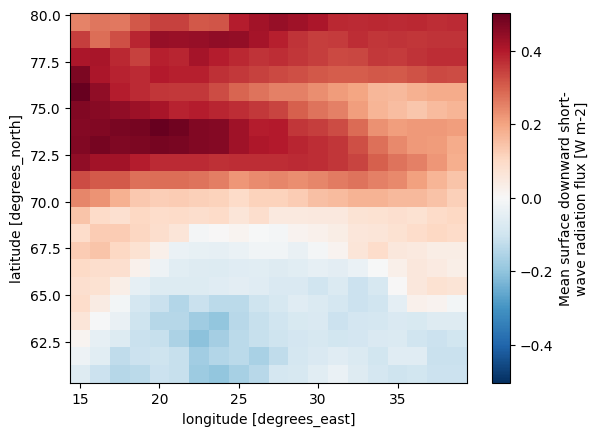

In [21]:
((debiased_coarse.mean(dim='time')-obs_coarse.mean(dim='time'))/obs_coarse.mean(dim='time')*100).plot()



### Spatial disaggregation sub-steps (Stage 2)

The single `_apply_spatial_downscaling()` call is expanded into five named
intermediates (Cells A–E) plus a consistency check (Cell F), so each step
can be inspected independently. These mirror the internals of
`downscale_from_coarse()` exactly.

> **Cell A** and **Cell B** compute the obs climatology, which is
> scenario-independent. The arrays will be reused in Stage 3 (starting from
> Cell C) so those cells do not need to rerun them.



  obs_fine_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 81, 'lon': 97}
  NaN:   0.0000 (0.00%)


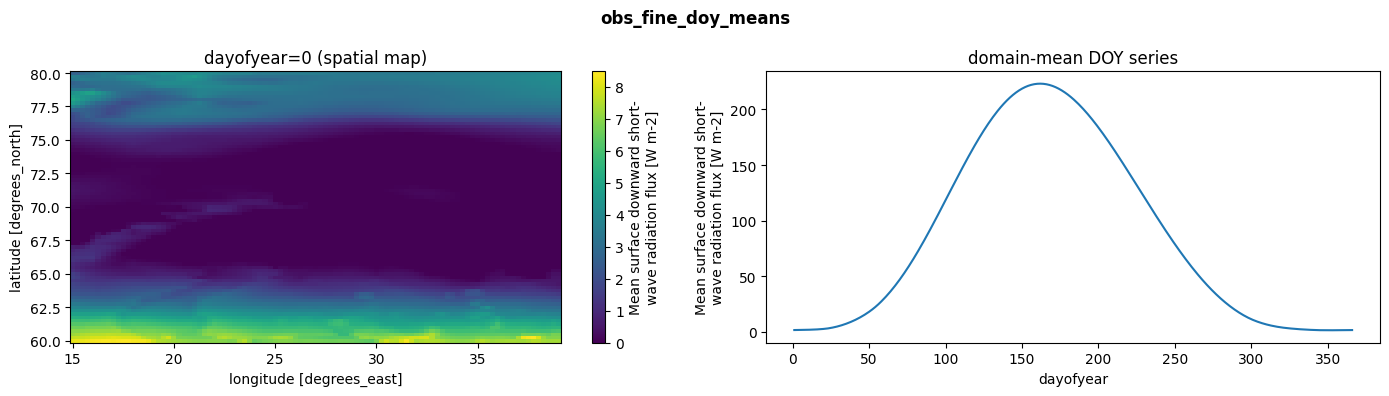

CPU times: user 625 ms, sys: 0 ns, total: 625 ms
Wall time: 410 ms


In [22]:
%%time
# ── Cell A: fine-grid day-of-year climatology ──────────────────────────────────
# Uses the downscaling_clim_method from config (typically "fft" for most vars).
obs_fine_doy_means = calculate_doy_means(obs_fine_s2, clim_method=config.downscaling_clim_method, allow_negative_values=False)
obs_fine_doy_means = inspect(obs_fine_doy_means, "obs_fine_doy_means")

## Inspect the difference if you were to create `obs_fine_doy_means` using the two different options of `clim_method`: simple or fft.

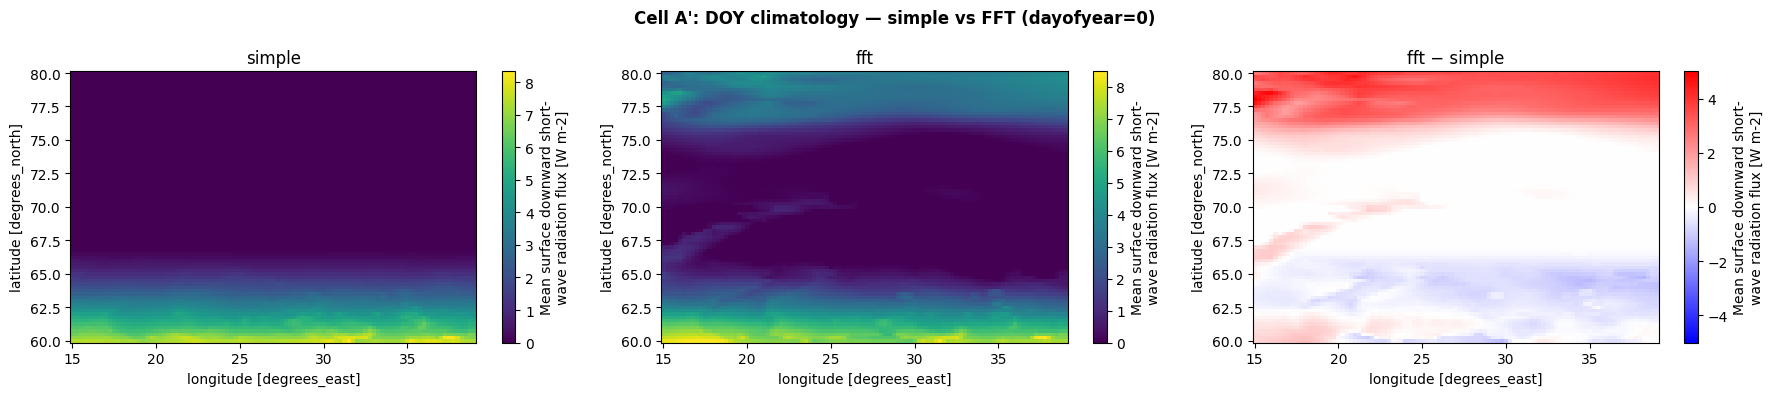

CPU times: user 961 ms, sys: 46 μs, total: 961 ms
Wall time: 548 ms


In [23]:
%%time
# ── Cell A': FFT vs simple climatology comparison ─────────────────────────────
# Three-panel map: simple | fft | diff (bwr, center=0) for dayofyear=0.
# Reveals FFT-smoothing artifacts found in prior QA notebooks.
obs_fine_doy_means_simple = calculate_doy_means(obs_fine_s2, clim_method="simple", allow_negative_values=False)
obs_fine_doy_means_fft = calculate_doy_means(obs_fine_s2, clim_method="fft", allow_negative_values=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Cell A': DOY climatology — simple vs FFT (dayofyear=0)", fontweight="bold")
kw = dict(add_colorbar=True)
obs_fine_doy_means_simple.isel(dayofyear=0).plot(ax=axes[0], **kw)
axes[0].set_title("simple")
obs_fine_doy_means_fft.isel(dayofyear=0).plot(ax=axes[1], **kw)
axes[1].set_title("fft")
diff = (obs_fine_doy_means_fft - obs_fine_doy_means_simple).isel(dayofyear=0)
diff.plot(ax=axes[2], cmap="bwr", center=0, **kw)
axes[2].set_title("fft − simple")
plt.tight_layout()
plt.show()

## Coarsen the finescale doy means. This creates the a coarse doy dataset that is consistent with the smoothed finescale DOY means.


  obs_coarse_doy_means
  (QA checks skipped — dayofyear dimension, no time axis)
  shape: {'dayofyear': 366, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


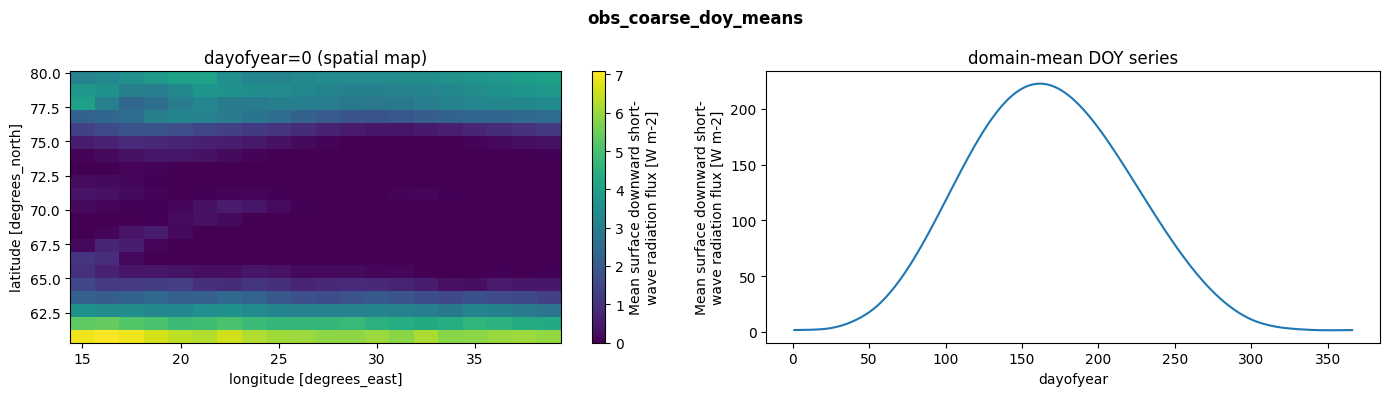

In [24]:
# ── Cell B: coarsen DOY climatology to GCM grid ───────────────────────────────
obs_coarse_doy_means = interpolate_fine_to_coarse_grid(
    da_fine_to_coarsen=obs_fine_doy_means, da_coarse_grid=obs_coarse
)
obs_coarse_doy_means = inspect(obs_coarse_doy_means, "obs_coarse_doy_means")


  residuals_coarse
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 0.02% of values outside [-1, 1200]
        out_of_range_fraction: 0.0002293917418972917
        actual_min: 0.0
        actual_max: 10000.0
        expected_min: -1
        expected_max: 1200
  ✓ sporadic_nan_days: PASS
  shape: {'time': 13514, 'lat': 21, 'lon': 20}
  NaN:   0.0000 (0.00%)


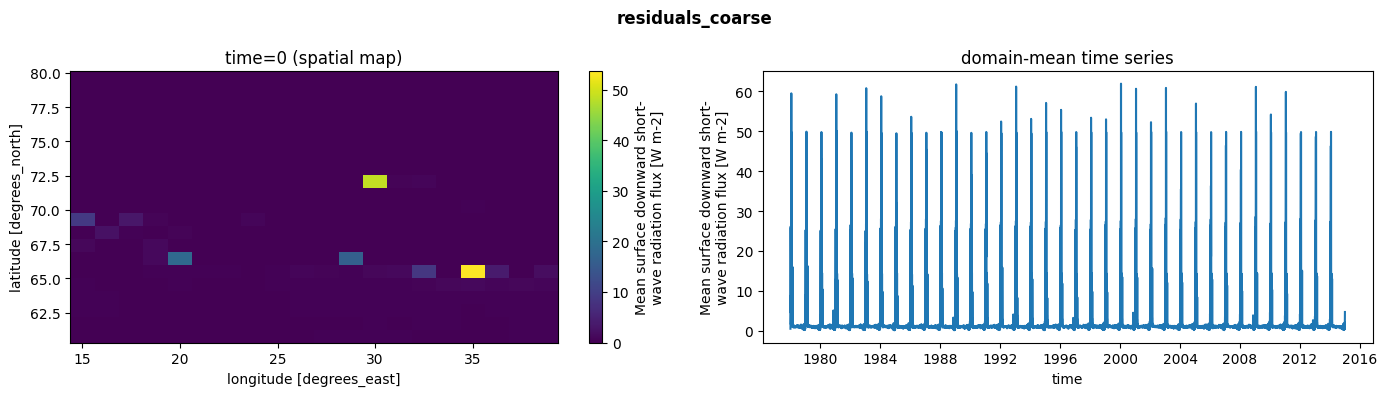

In [52]:
high_clip = 10000
clip100 = 100
clip10 = 10
# ── Cell C: coarse spatial residuals (debiased − coarse climatology) ──────────
# residuals_coarse is how different that debiased GCM pixel on that day is from the typical 
# (coarse) obs on that same day of year. for instance, for temperature, it says
# "the debiased GCM here for this day is 3 degrees warmer than the mean obs here" or "the debiased GCM
# here for this day is 10x wetter than the mean". it can happen, particularly for precipitation,
# if there were essentially no big storms in the obs for that pixel, and in the GCM it happens to get a storm,
# that the residual can be very high.
if config.downscaling_method == "additive":
    residuals_coarse = debiased_coarse.groupby("time.dayofyear") - obs_coarse_doy_means
elif config.downscaling_method == "multiplicative":
    zero_clim = obs_coarse_doy_means == 0
    obs_coarse_doy_means_safe = obs_coarse_doy_means.where(~zero_clim)  # zeros -> NaN


    residuals_coarse = debiased_coarse.groupby("time.dayofyear") / obs_coarse_doy_means_safe

    # Force ratio to 0 exactly where the coarse climatology was zero.
    # Broadcast the per-DOY zero mask back onto the time axis.
    zero_clim_on_time = zero_clim.sel(dayofyear=debiased_coarse["time"].dt.dayofyear)
    residuals_coarse = residuals_coarse.where(~zero_clim_on_time, 0.0).clip(max=high_clip)
    residuals_coarse_clipped10 = residuals_coarse.clip(max=clip10)
    residuals_coarse_clipped100 = residuals_coarse.clip(max=clip100)
residuals_coarse = inspect(residuals_coarse, "residuals_coarse")

## Inspect the largest residual along the time dimension

To test how big the residuals can get, let's find:
1. what places have situations that have factors over 100 (if we were to clip to 100 where would we mask out) and 
2. what the raw/downscaled weather for those individual days looks like when the factors are over 100.

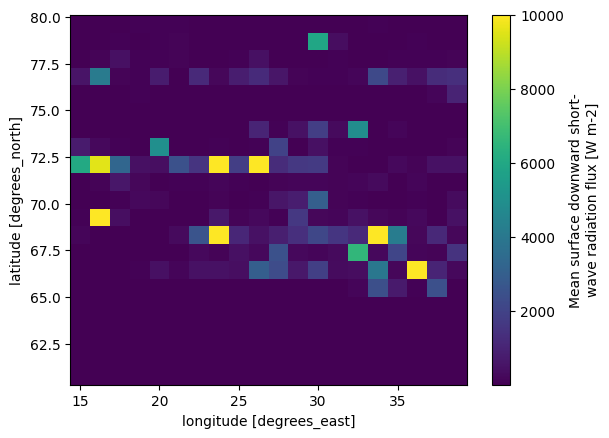

In [26]:
residuals_coarse.max(dim='time').plot(vmax=10000)

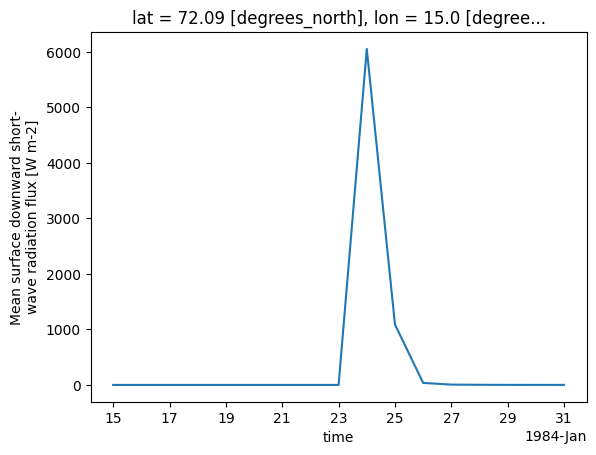

In [49]:
residuals_coarse.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').sel(time=slice('1984-01-15', '1984-01-31')).plot()

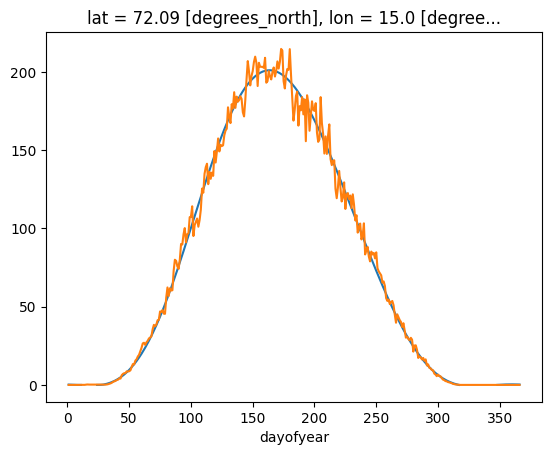

In [90]:
obs_coarse_doy_means_safe.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').plot()
debiased_coarse.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').groupby("time.dayofyear").mean().plot()

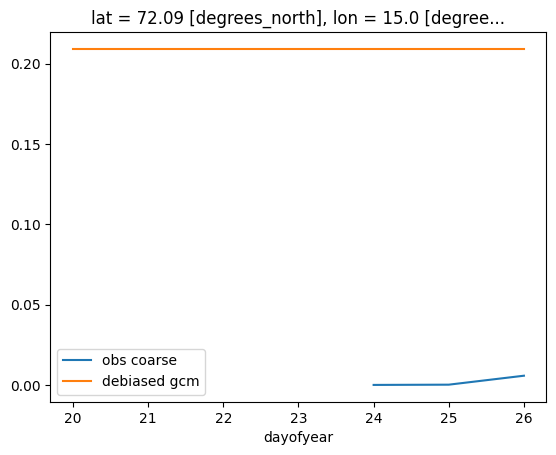

In [93]:
obs_coarse_doy_means_safe.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').sel(dayofyear=slice(20,26)).plot(label='obs coarse')
debiased_coarse.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').groupby("time.dayofyear").mean().sel(dayofyear=slice(20,26)).plot(label='debiased gcm')
plt.legend()

Because on this one day the debiased gcm had a value of 0.2 while the obs was very tiny but non-zero, it created a very large residual that gets carried through!

In [98]:
obs_problem_value = obs_coarse_doy_means_safe.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').sel(dayofyear=24).values
debiased_gcm_problem_day_value = debiased_coarse.sel(lon=-26, 
                     lat=72.4, 
                     method='nearest').groupby("time.dayofyear").mean().sel(dayofyear=24).values
residual_problem_day_value = debiased_gcm_problem_day_value/obs_problem_value
print(f'obs problem value is: {obs_problem_value}')
print(f'debiased gcm problem value is: {debiased_gcm_problem_day_value}')
print(f'residual problem value is: {residual_problem_day_value}')


obs problem value is: 3.455966361798346e-05
debiased gcm problem value is: 0.20916283130645752
residual problem value is: 6052.22412109375


`'1984-01-24'` is a day that had a huge residual factor at the pixel (72.4, -26). let's look at what that day's solar radiation in the GCM looked like.

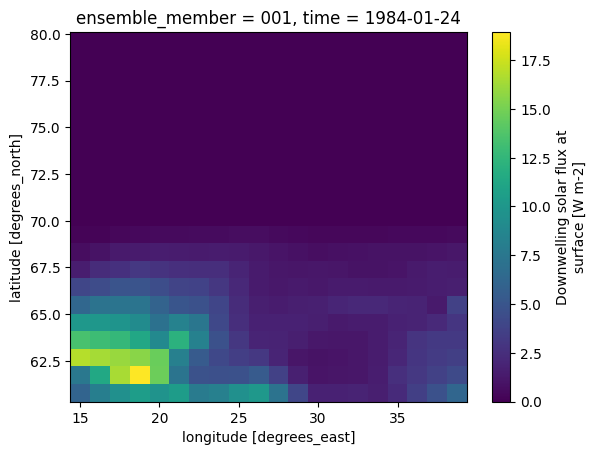

In [54]:
model_hist.sel(time='1984-01-24').plot()

Start of the year has lots of zero solar radiation.

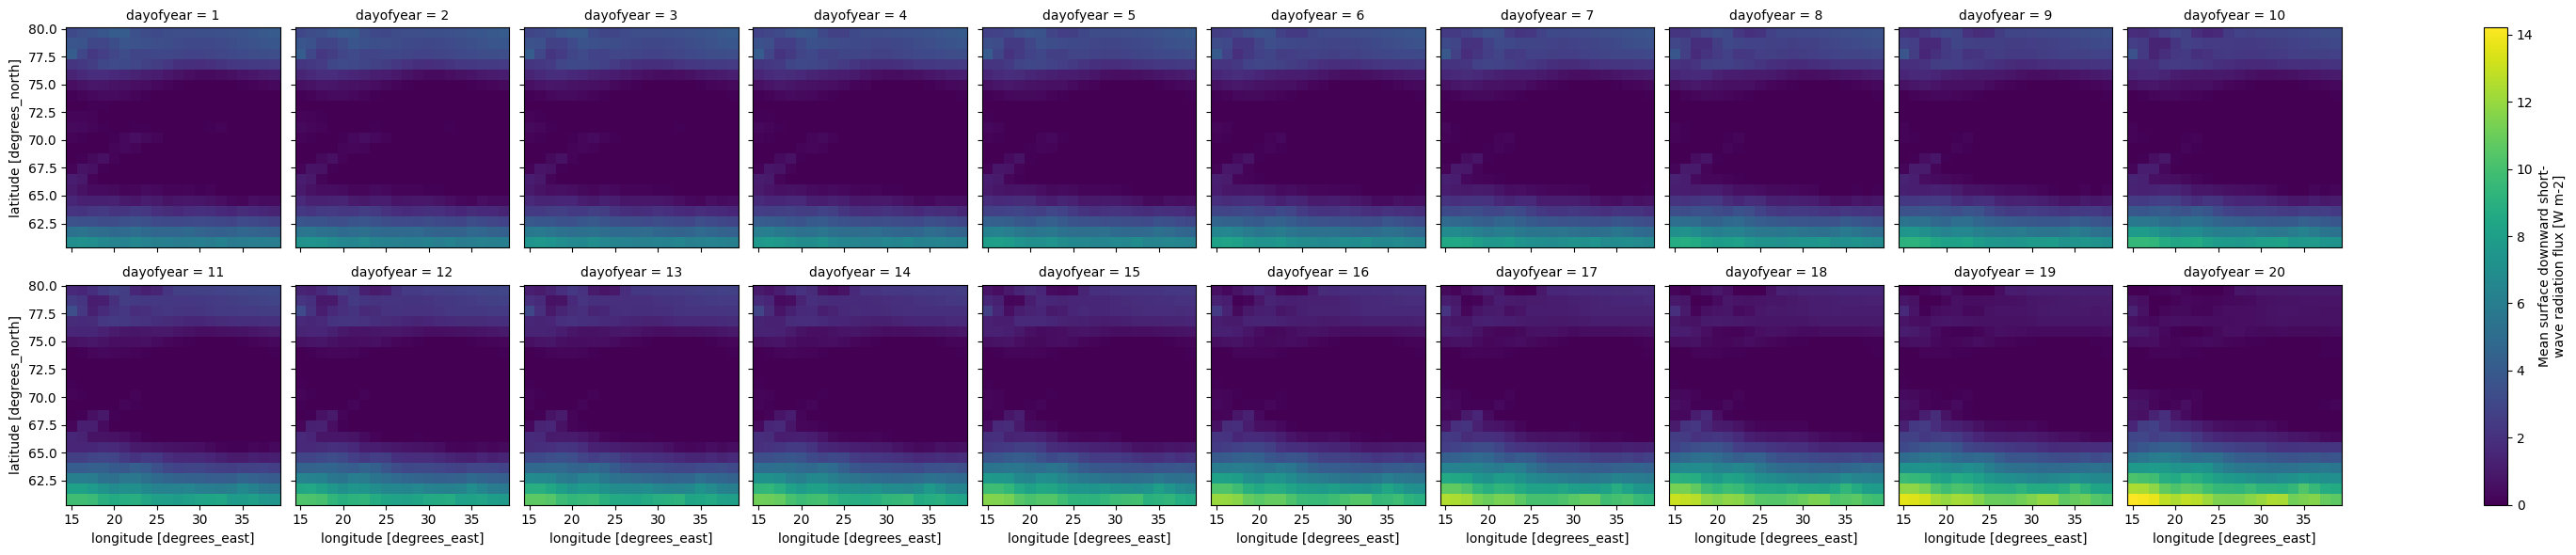

In [33]:
(obs_coarse_doy_means.sel(dayofyear=slice(1,20)).plot(col='dayofyear', col_wrap=10))

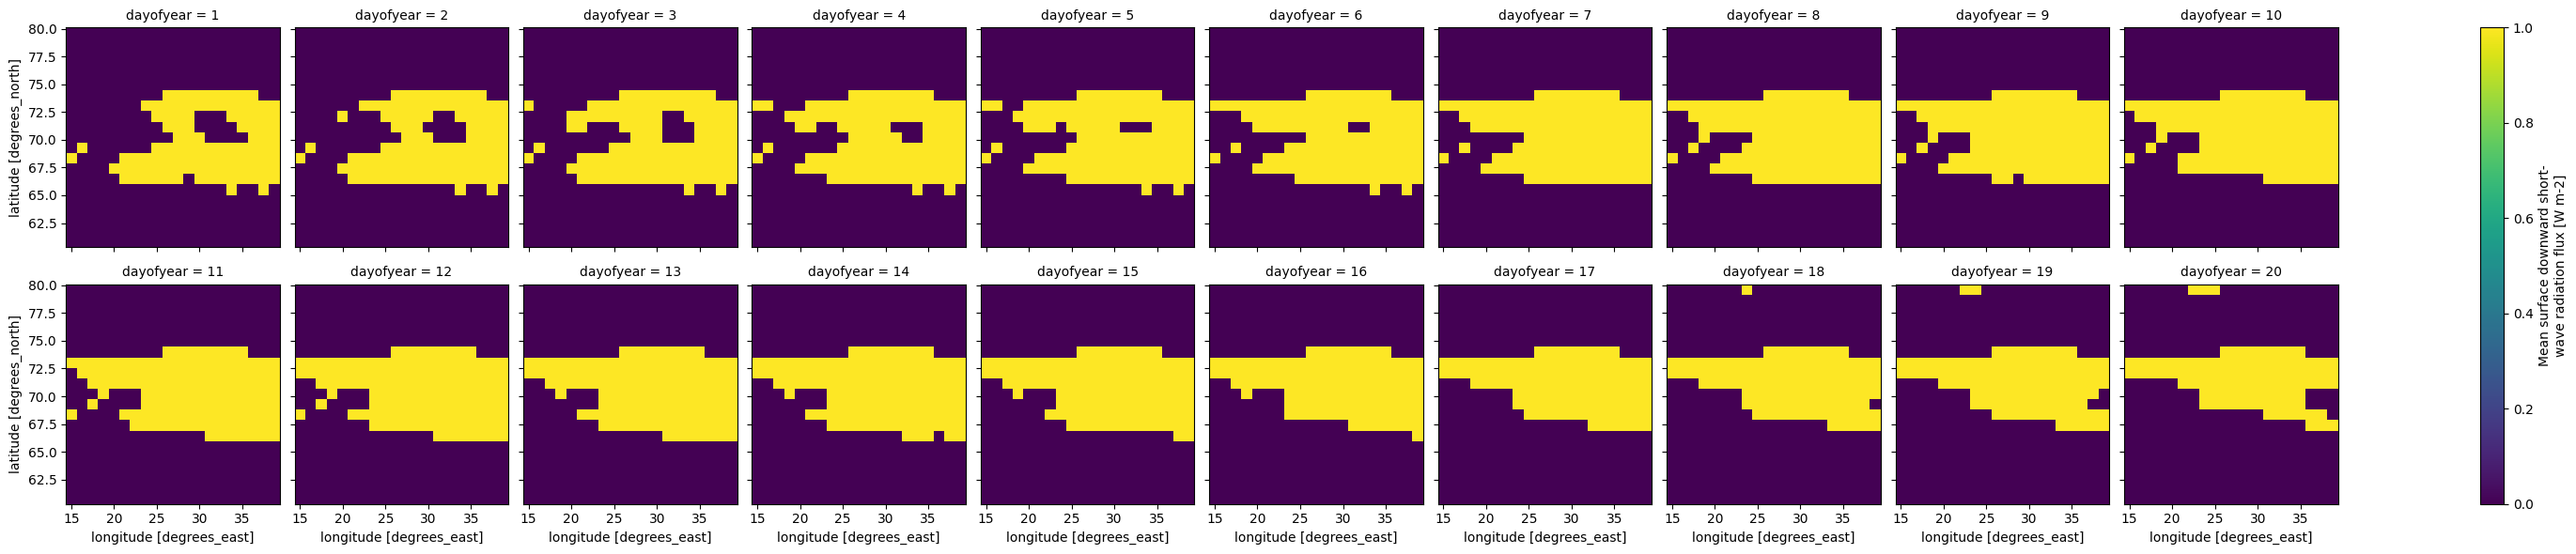

In [34]:
(obs_coarse_doy_means.sel(dayofyear=slice(1,20))==0).plot(col='dayofyear', col_wrap=10)

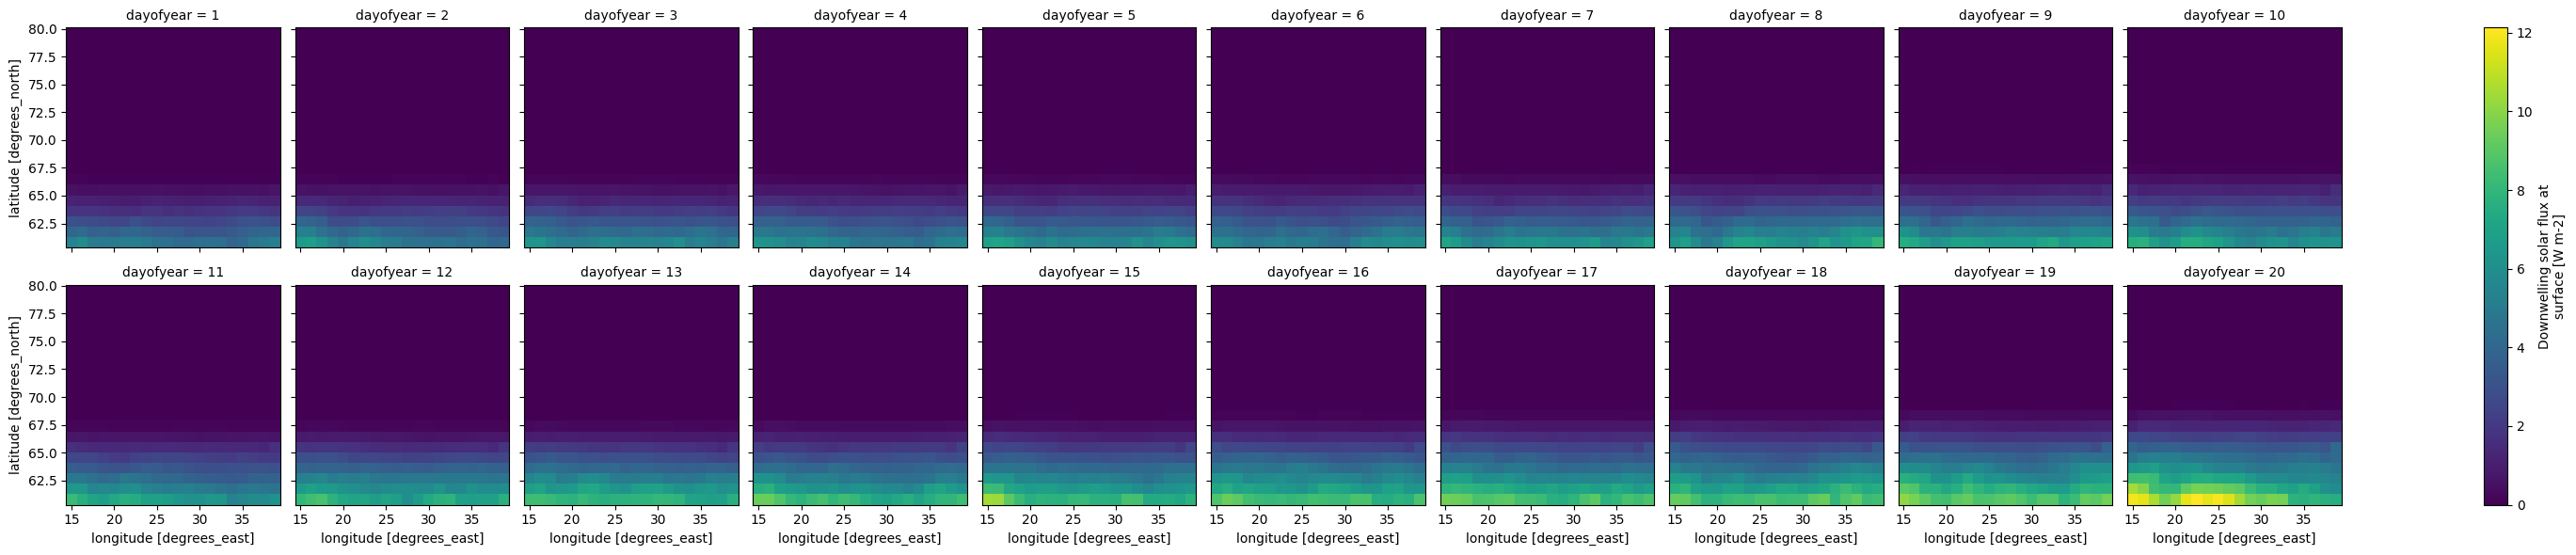

In [35]:
(model_hist.groupby('time.dayofyear').mean().sel(dayofyear=slice(1,20)).plot(col='dayofyear', col_wrap=10))

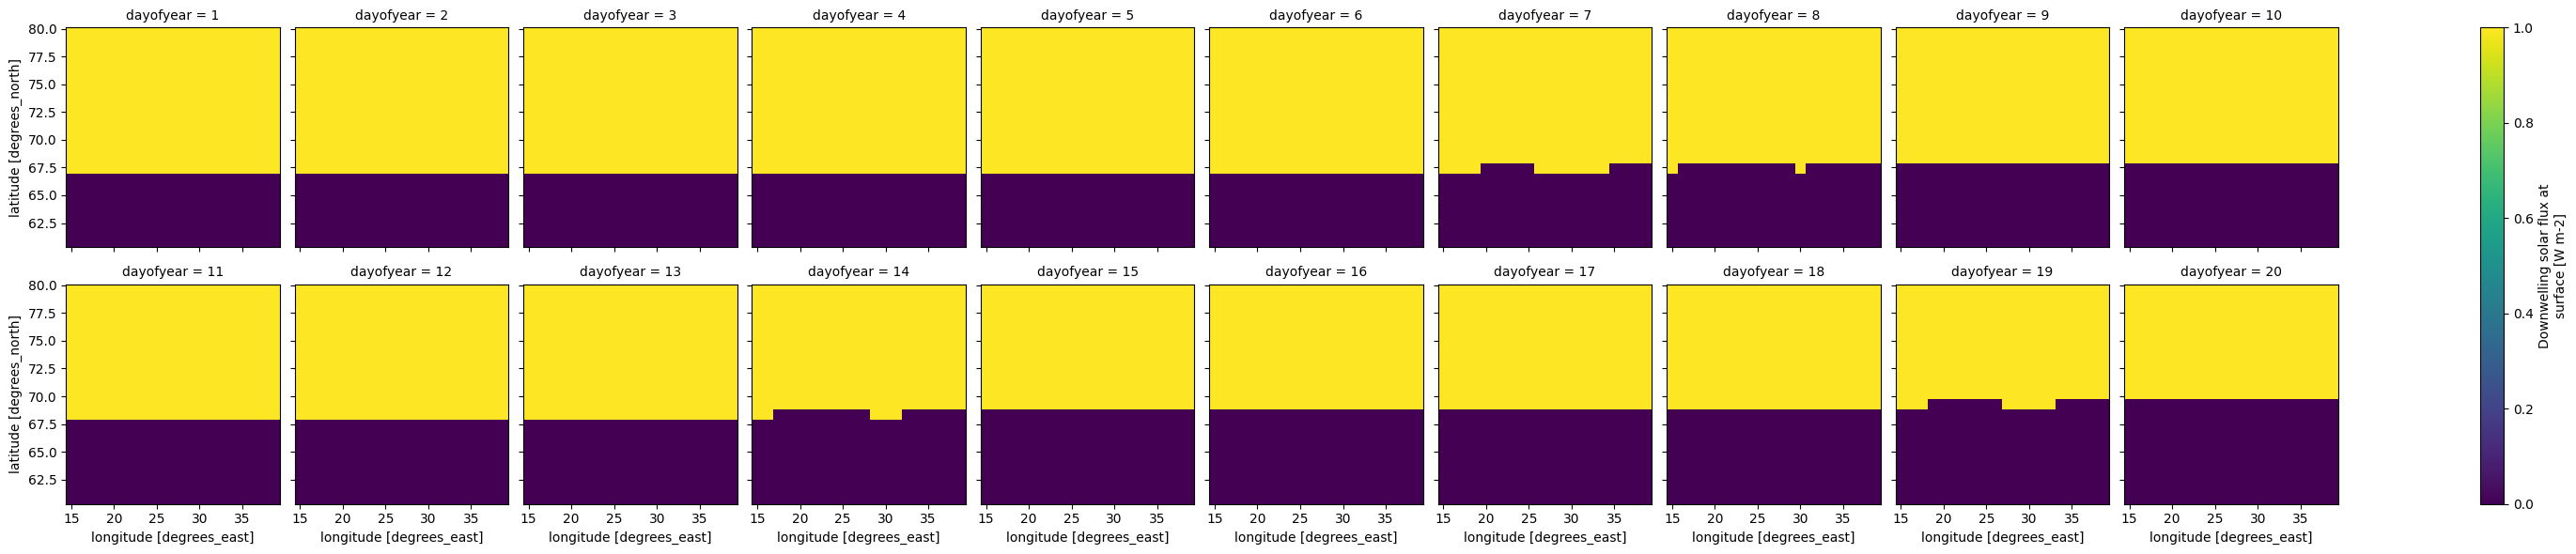

In [41]:
(model_hist.groupby('time.dayofyear').mean()==0).sel(dayofyear=slice(1,20)).plot(col='dayofyear', col_wrap=10)

For solar radiation, in contrast to precipitation, there are situations where obs has non-zero values and the GCM has zero values. Let's see if that causes problems!

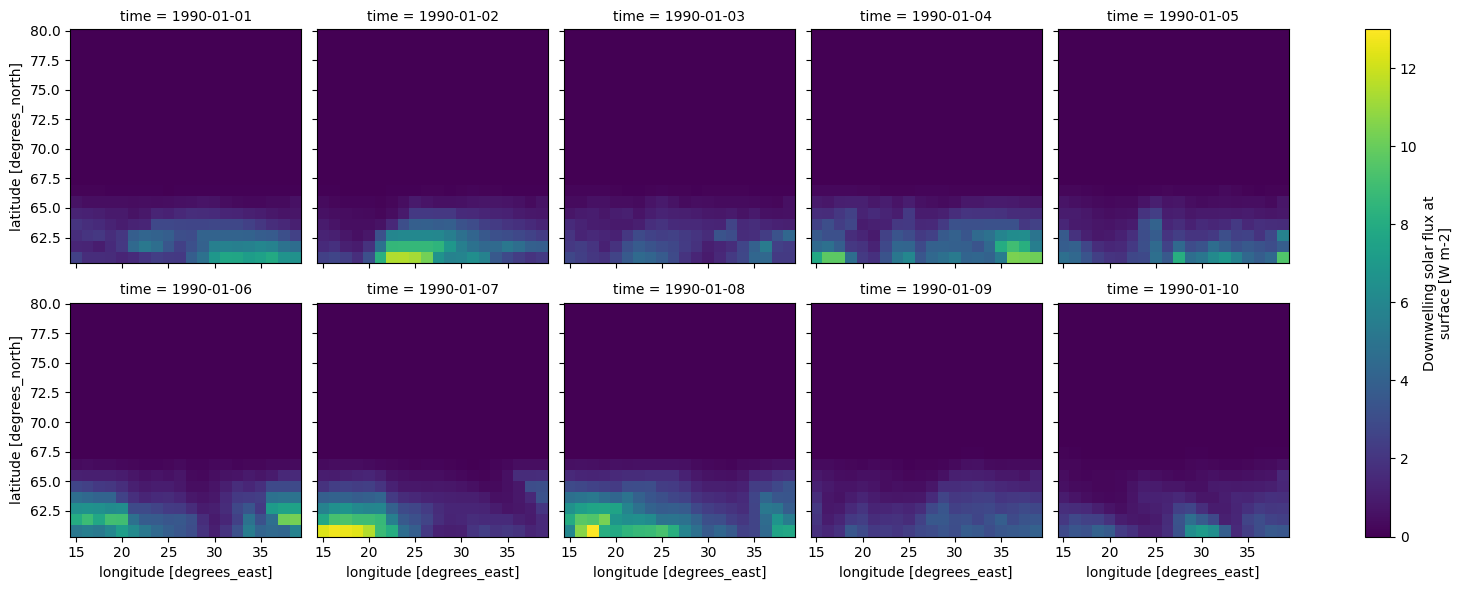

In [43]:
model_hist.sel(time=slice('1990-01-01', '1990-01-10')).plot(col='time', col_wrap=5)


  residuals_fine
  ✓ all_nan: PASS
  ✗ out_of_range: FAIL — 0.02% of values outside [-1, 1200]
        out_of_range_fraction: 0.00024583559436304735
        actual_min: 0.0
        actual_max: 9819.4931640625
        expected_min: -1
        expected_max: 1200
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


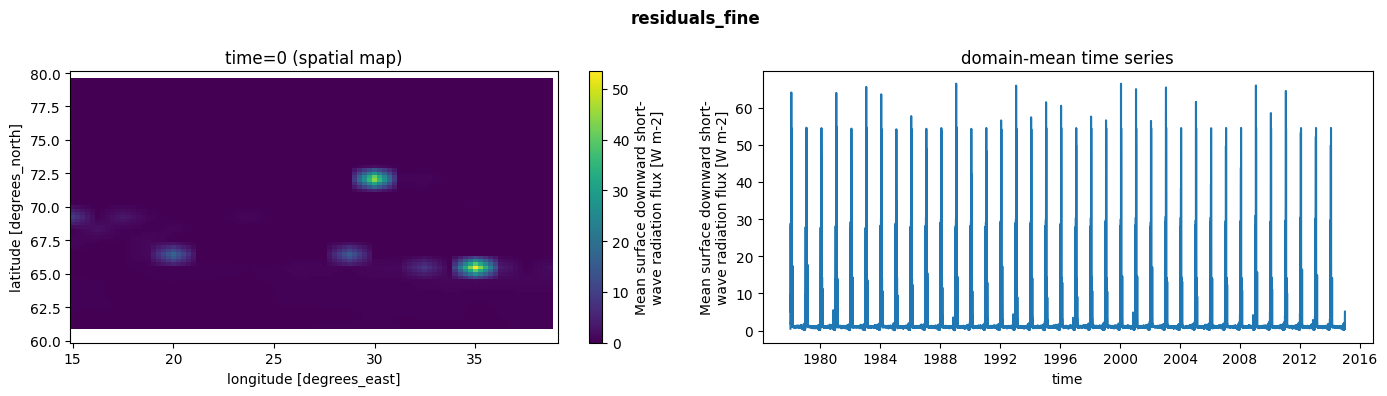

In [56]:
# ── Cell D: interpolate residuals to fine grid ────────────────────────────────
residuals_fine = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse, da_fine_grid=obs_fine_s2
)
residuals_fine = inspect(residuals_fine, "residuals_fine")

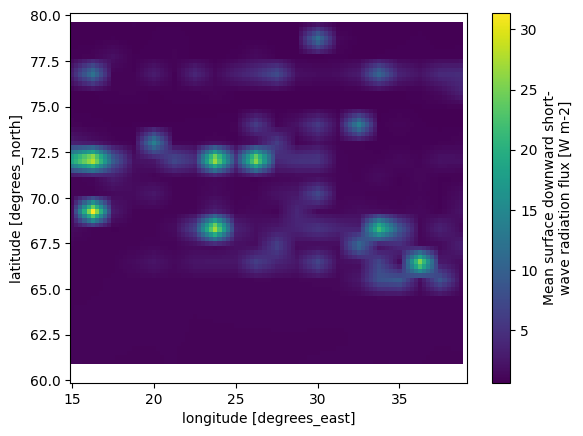

In [57]:
residuals_fine.mean(dim='time').plot()


  residuals_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


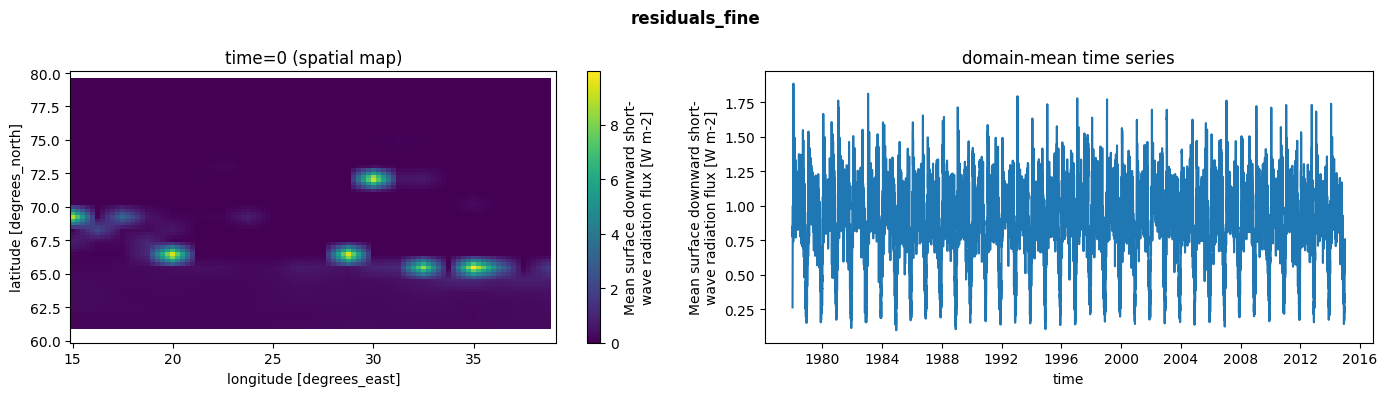

In [58]:
residuals_fine_clipped10 = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse_clipped10, da_fine_grid=obs_fine_s2
)
residuals_fine_clipped10 = inspect(residuals_fine_clipped10, "residuals_fine")

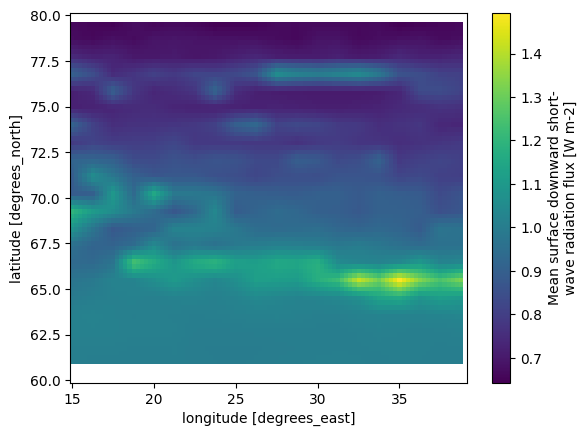

In [63]:
residuals_fine_clipped10.mean(dim='time').plot()


  residuals_fine
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


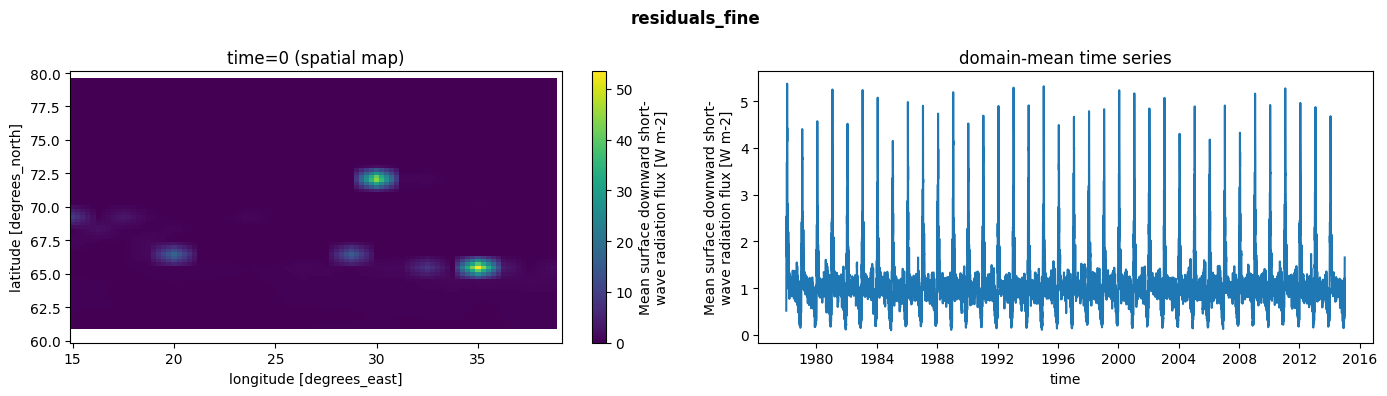

In [60]:
residuals_fine_clipped100 = interpolate_coarse_to_fine_grid(
    da_coarse_to_regrid=residuals_coarse_clipped100, da_fine_grid=obs_fine_s2
)
residuals_fine_clipped100 = inspect(residuals_fine_clipped100, "residuals_fine")

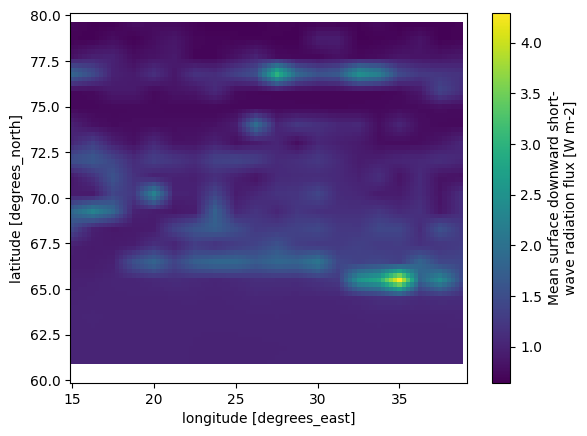

In [62]:
residuals_fine_clipped100.mean(dim='time').plot()


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


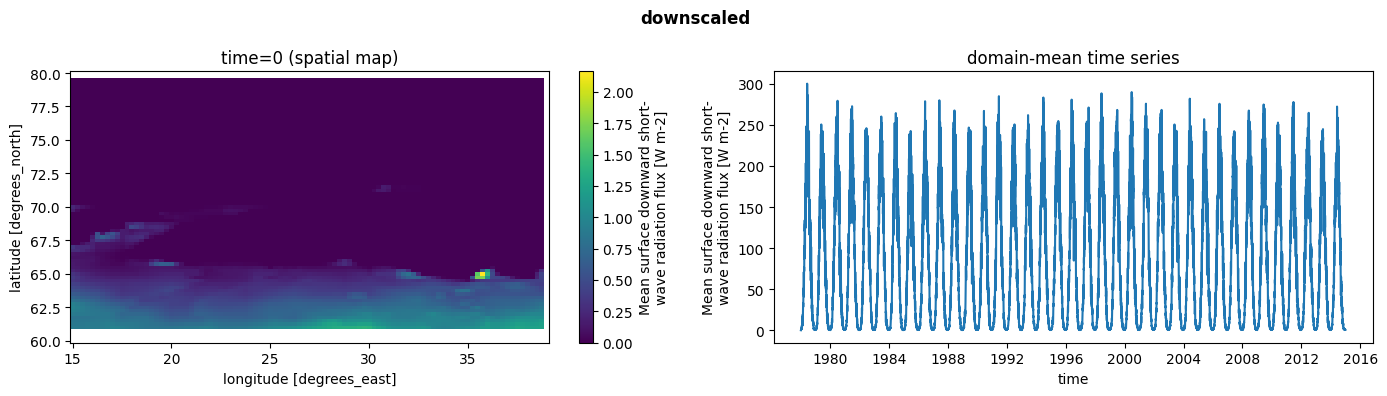

In [64]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.downscaling_method == "additive":
    downscaled = residuals_fine.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    downscaled = residuals_fine.groupby("time.dayofyear") * obs_fine_doy_means
downscaled = inspect(downscaled, "downscaled")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


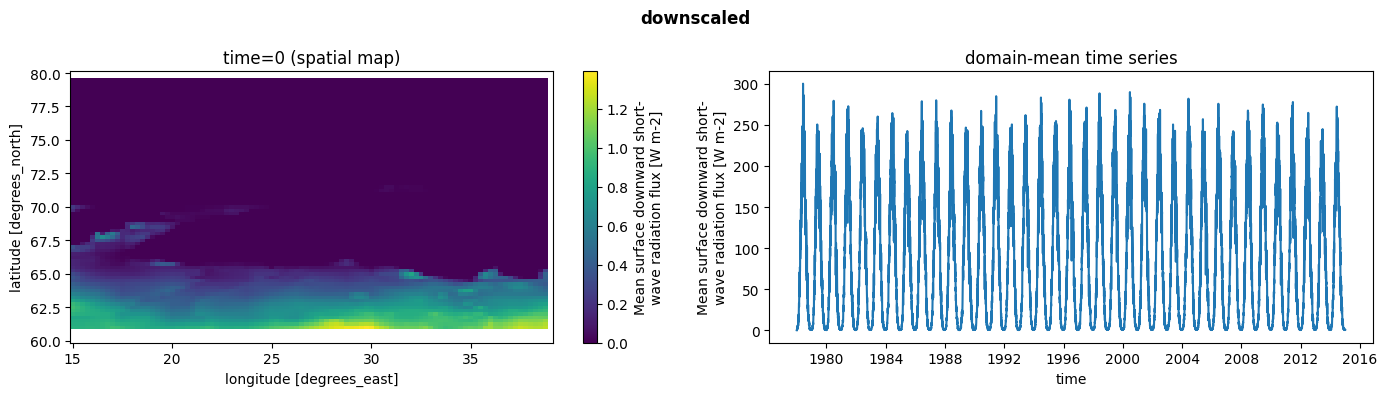

In [65]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.downscaling_method == "additive":
    downscaled_clipped10 = residuals_fine_clipped10.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    downscaled_clipped10 = residuals_fine_clipped10.groupby("time.dayofyear") * obs_fine_doy_means
downscaled_clipped10 = inspect(downscaled_clipped10, "downscaled")


  downscaled
  ✓ all_nan: PASS
  ✓ out_of_range: PASS
  ✗ sporadic_nan_days: FAIL — 13514 time steps have partial NaN coverage
        sporadic_nan_day_count: 13514
        sample_dates: ['1978-01-01', '1978-01-02', '1978-01-03', '1978-01-04', '1978-01-05']
  shape: {'time': 13514, 'lat': 81, 'lon': 97}
  NaN:   0.0836 (8.36%)


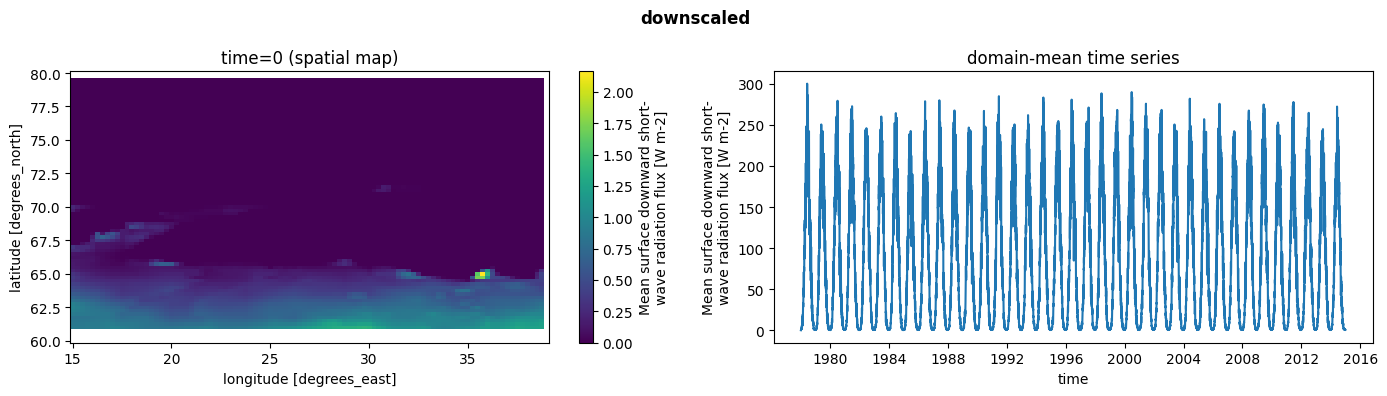

In [66]:
# ── Cell E: reapply fine-grid DOY climatology → final downscaled field ─────────
if config.downscaling_method == "additive":
    downscaled_clipped100 = residuals_fine_clipped100.groupby("time.dayofyear") + obs_fine_doy_means
elif config.downscaling_method == "multiplicative":
    downscaled_clipped100 = residuals_fine_clipped100.groupby("time.dayofyear") * obs_fine_doy_means
downscaled_clipped100 = inspect(downscaled_clipped100, "downscaled")

There are NaN values but only around edges.

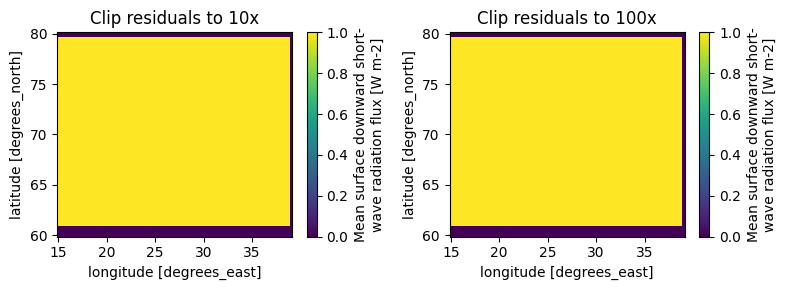

In [67]:
fig, axarr = plt.subplots(ncols=2, figsize=(8,3))
(downscaled_clipped10.isnull().sum(dim='time')==0).plot(ax=axarr[0])
axarr[0].set_title('Clip residuals to 10x')
(downscaled_clipped100.isnull().sum(dim='time')==0).plot(ax=axarr[1])
axarr[1].set_title('Clip residuals to 100x')
plt.tight_layout()

There are no negative rsds values.

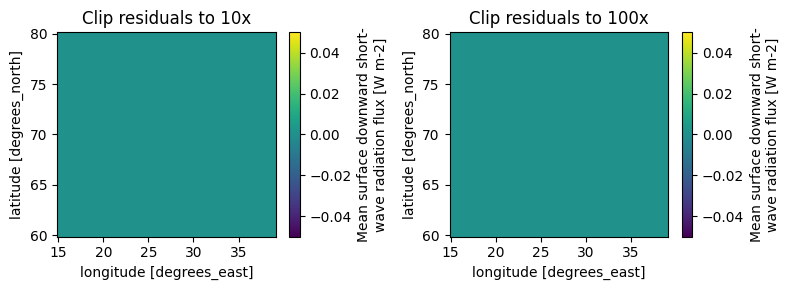

In [68]:
fig, axarr = plt.subplots(ncols=2, figsize=(8,3))
(downscaled_clipped10<0).sum(dim='time').plot(ax=axarr[0])
axarr[0].set_title('Clip residuals to 10x')
(downscaled_clipped100<0).sum(dim='time').plot(ax=axarr[1])
axarr[1].set_title('Clip residuals to 100x')
plt.tight_layout()

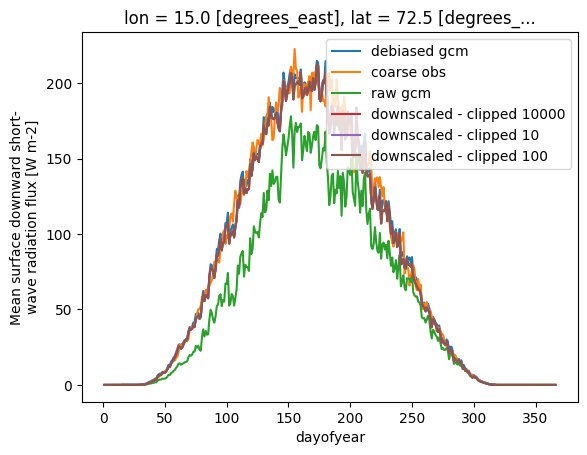

In [69]:
lat=72.4
lon=-26
debiased_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='debiased gcm')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='coarse obs')
model_hist.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='raw gcm')
downscaled.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {high_clip}')
downscaled_clipped10.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip10}')
downscaled_clipped100.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip100}')

plt.legend()

The effect on the downscaled data between the two kinds of residuals is shown below (clipped at 1e6 -essentially unclipped- minus the clipped at 10). The dataset based on residuals unclipped has more solar radiation (relatively) but it's tiny values because by definition the big residuals are multiplied by tiny solar radiation values. So, the clipping has less of an impact on rsds than it does on precipitation.

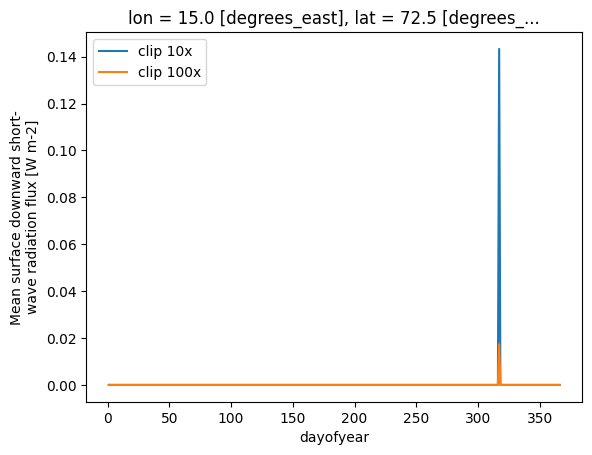

In [70]:
(downscaled-downscaled_clipped10).sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='clip 10x')
(downscaled-downscaled_clipped100).sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='clip 100x')
plt.legend()

Let's look for the weirdest circumstance - the largest absolute magnitude difference between the clipped and the non-clipped values.

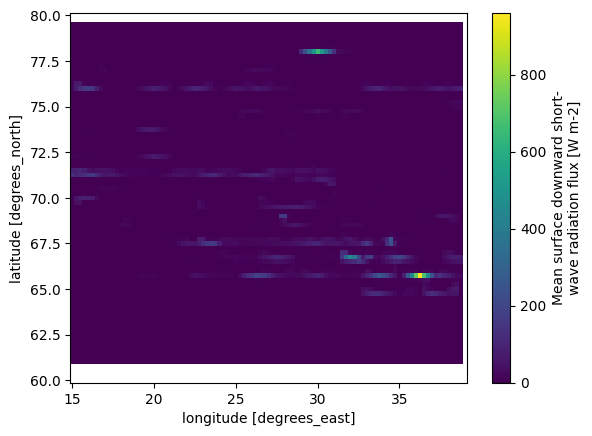

In [73]:
(downscaled-downscaled_clipped100).max(dim='time').plot()

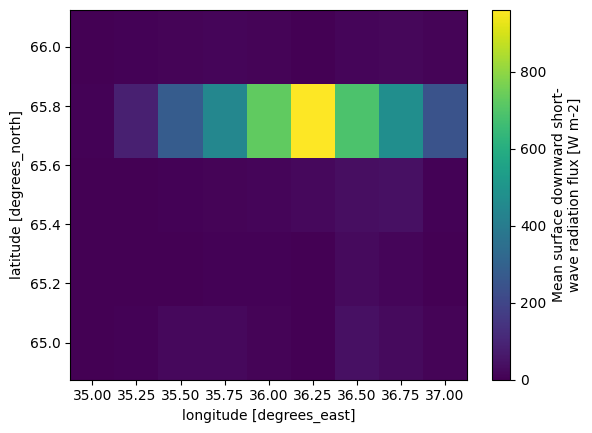

In [76]:
(downscaled-downscaled_clipped100).max(dim='time').sel(lat=slice(65, 66), lon=slice(35,37)).plot()

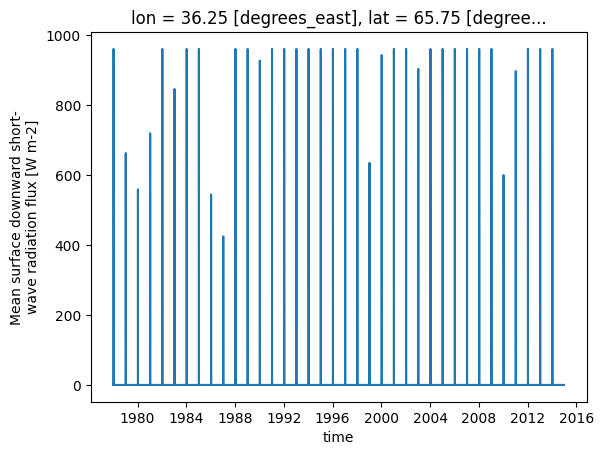

In [78]:
lat=65.8
lon=36.25
(downscaled-downscaled_clipped100).sel(lat=lat, lon=lon, method='nearest').plot()

In [ ]:
The weird residuals  always happens on the same 

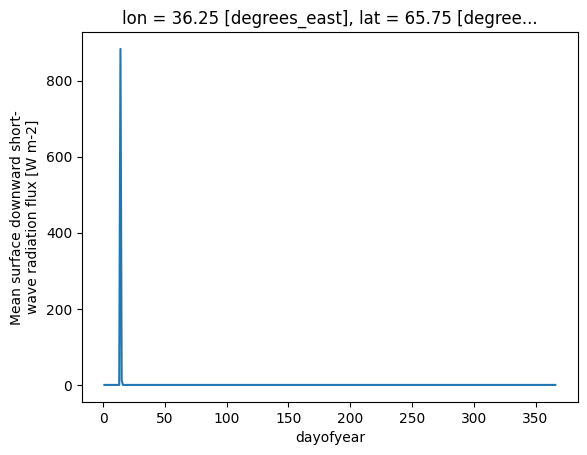

In [83]:
(downscaled-downscaled_clipped100).sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot()

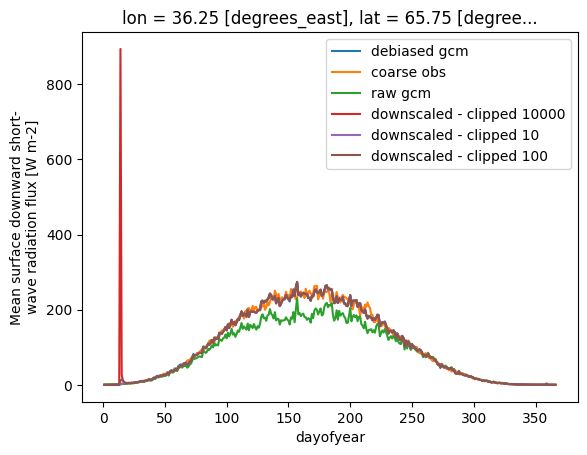

In [79]:
debiased_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='debiased gcm')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='coarse obs')
model_hist.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='raw gcm')
downscaled.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {high_clip}')
downscaled_clipped10.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip10}')
downscaled_clipped100.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip100}')

plt.legend()

Let's see the difference in the total annual solar radiation that is lost by imposing this clipping. To do that we create two downscaled datasets, one based on the high-clipping and one based on the low-clipping, calculate the average annual precipitation in each and then take a diff for each pixel from the obs. When we do this using a clipping of 10x for residuals, we end up losing a lot of the annual water in drier places. 

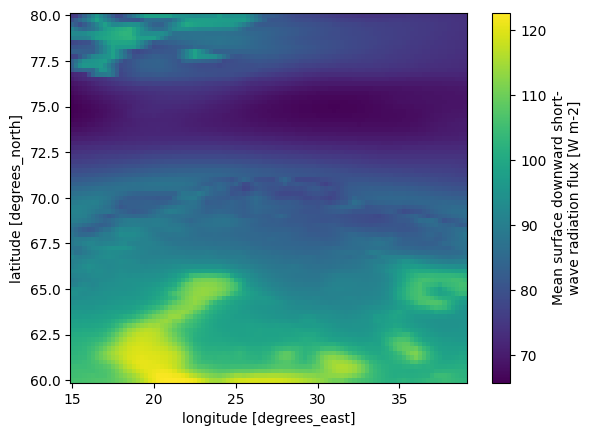

In [72]:
obs_fine.groupby('time.year').mean().mean(dim='year').plot()

In the below plot we see how we lose comparable amounts of solar radiation (and they're very tiny), but less so for 100x. If we wanted to tu

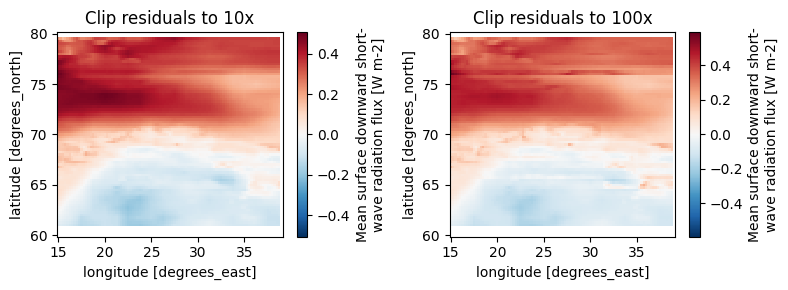

In [81]:
da_dict = {'Clip residuals to 10x': downscaled_clipped10,
           'Clip residuals to 100x': downscaled_clipped100}
fig, axarr = plt.subplots(ncols=2, figsize=(8,3))
for i, (label, da) in enumerate(da_dict.items()):
    (((da.groupby('time.year').mean().mean(dim='year') - \
       obs_fine.groupby('time.year').mean().mean(dim='year'))/obs_fine.groupby('time.year').mean().mean(dim='year'))*100).plot(ax=axarr[i])
    axarr[i].set_title(label)
plt.tight_layout()

Let's look at a pixel that has large relative losses in precip when clipping. 

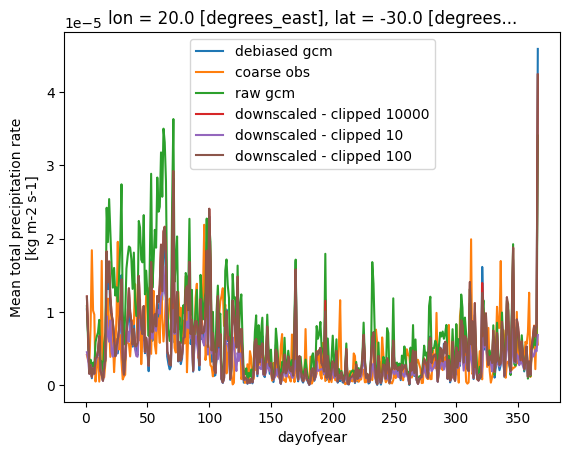

In [42]:
lat=-30
lon=20
debiased_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='debiased gcm')
obs_coarse.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='coarse obs')
model_hist.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label='raw gcm')
downscaled.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {high_clip}')
downscaled_clipped10.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip10}')
downscaled_clipped100.sel(lat=lat, lon=lon, method='nearest').groupby('time.dayofyear').mean().plot(label=f'downscaled - clipped {clip100}')

plt.legend()

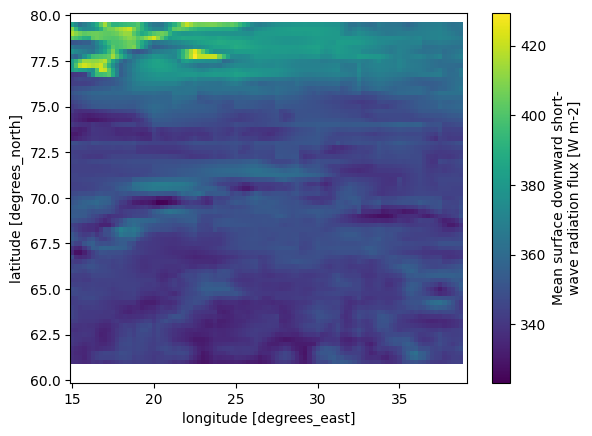

In [99]:
downscaled_clipped100.max(dim='time').plot()

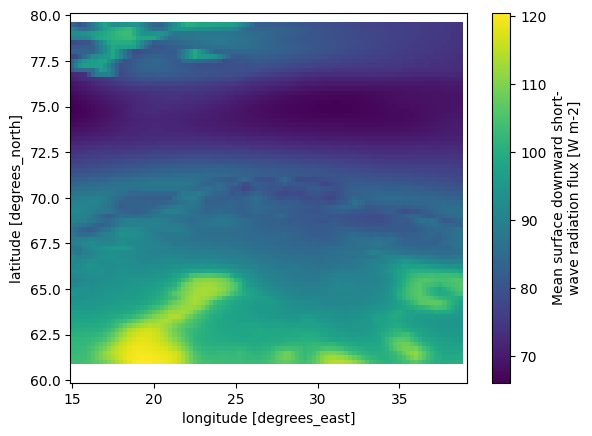

In [100]:
downscaled_clipped100.mean(dim='time').plot()